# results: bias in MLMs over time

In [1]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [2]:
# config
OUT_DIR = "results_crows_mlm"
BIAS_MLM_CSV = os.path.join(OUT_DIR, "crows_bias_mlm_all_models.csv")

df_mlm = pd.read_csv(BIAS_MLM_CSV).sort_values(["year","model_id"]).reset_index(drop=True)

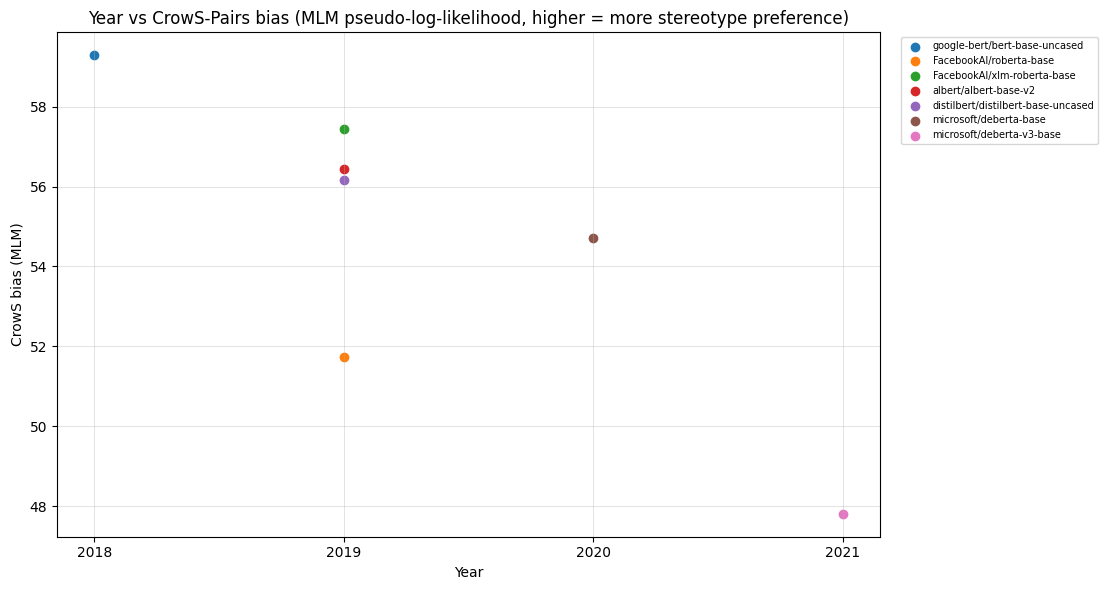

In [3]:
def scatter_models_legend(df, xcol, ycol, title, xlabel, ylabel, x_is_year=False):
    fig, ax = plt.subplots(figsize=(15, 6))
    for model_id, sub in df.groupby("model_id", sort=False):
        x = sub[xcol].astype(int) if x_is_year else sub[xcol].astype(float)
        y = sub[ycol].astype(float)
        ax.scatter(x, y, label=model_id)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if x_is_year:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        years = sorted(df[xcol].astype(int).unique())
        ax.set_xticks(years)

    ax.grid(True, linewidth=0.5, alpha=0.5)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
    fig.tight_layout(rect=[0, 0, 0.75, 1])
    plt.show()

scatter_models_legend(
    df_mlm, "year", "crows_bias_mlm",
    "Year vs CrowS-Pairs bias (MLM pseudo-log-likelihood, higher = more stereotype preference)",
    "Year", "CrowS bias (MLM)", x_is_year=True
)